# 🛍️ Online Retail Sales Analysis

## Business Problem

This project analyzes one year of online retail transactions to uncover sales trends, customer purchasing behavior, product performance, and business opportunities.

The objective is to transform raw transactional data into actionable insights that can support inventory planning, marketing decisions, and revenue optimization.

---

## Objectives

- Clean and prepare raw retail transaction data.
- Handle missing values and inconsistent product descriptions.
- Perform exploratory data analysis (EDA).
- Identify top-performing products and countries.
- Analyze customer behavior and cancellations.
- Apply Pareto and ABC Analysis for inventory prioritization.
- Build an interactive Power BI dashboard for business reporting.

# 📂 Dataset Overview

The **Online Retail Dataset** contains transactional records from an online retail company over approximately one year.

Each row represents a purchased product within a customer invoice.

## Dataset Features

- **InvoiceNo** – Unique invoice number.
- **StockCode** – Unique identifier for each product.
- **Description** – Product description.
- **Quantity** – Number of units purchased.
- **InvoiceDate** – Date and time of the transaction.
- **UnitPrice** – Price per product.
- **CustomerID** – Unique customer identifier.
- **Country** – Country where the order was placed.


In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns


# 🧹 Data Cleaning

Before performing any analysis, the dataset must be cleaned to ensure reliable and meaningful insights.

## Cleaning Tasks Performed

- Checked for missing values.
- Filled missing product descriptions using the corresponding StockCode.
- Categorized remaining missing descriptions as **"Other"**.
- Preserved missing Customer IDs by treating them as anonymous customers.
- Verified data consistency.
- Prepared the dataset for feature engineering.

In [5]:
from pathlib import Path

# Project Root
PROJECT_DIR = Path.cwd().parent

# Data
DATA_DIR = PROJECT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

# Notebooks
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"

# Reports
REPORTS_DIR = PROJECT_DIR / "reports"

# Figures
FIGURES_DIR = PROJECT_DIR / "figures"

# Power BI Dashboard
DASHBOARD_DIR = PROJECT_DIR / "dashboard"

# Models (for future ML projects)
MODELS_DIR = PROJECT_DIR / "models"

In [12]:
df = pd.read_excel(RAW_DATA_DIR / "Online Retail.xlsx")
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [15]:
df['StockCode'].nunique()

4070

In [16]:
df.groupby('StockCode')['Description'].nunique().sort_values(ascending=False).head(20)

StockCode
20713     8
23084     7
21830     6
85175     6
72807A    5
85172     5
23343     5
21181     5
23131     5
85185B    4
85123A    4
46000S    4
72802A    4
72807B    4
22837     4
23196     4
22812     4
22501     4
22121     4
21823     4
Name: Description, dtype: int64

In [17]:
df[df["StockCode"]==20713]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
522,536409,20713,JUMBO BAG OWLS,1,2010-12-01 11:45:00,1.95,17908.0,United Kingdom
1117,536527,20713,JUMBO BAG OWLS,10,2010-12-01 13:04:00,1.95,12662.0,Germany
1439,536542,20713,JUMBO BAG OWLS,30,2010-12-01 14:11:00,1.95,16456.0,United Kingdom
6381,536938,20713,JUMBO BAG OWLS,20,2010-12-03 12:05:00,1.95,14680.0,United Kingdom
7788,537054,20713,JUMBO BAG OWLS,3,2010-12-05 11:40:00,1.95,16931.0,United Kingdom
...,...,...,...,...,...,...,...,...
538154,581400,20713,JUMBO BAG OWLS,1,2011-12-08 13:36:00,2.08,14056.0,United Kingdom
538601,581412,20713,JUMBO BAG OWLS,5,2011-12-08 14:38:00,2.08,14415.0,United Kingdom
539382,581439,20713,JUMBO BAG OWLS,1,2011-12-08 16:30:00,4.13,NaN,United Kingdom
541327,581498,20713,JUMBO BAG OWLS,8,2011-12-09 10:26:00,4.13,NaN,United Kingdom


In [18]:
df.groupby('Description').apply(lambda x: x[x["StockCode"]==20713]).head(400)

InvoiceNo StockCode  Quantity         InvoiceDate  \
Description                                                               
Found          414145    572345     20713       100 2011-10-24 10:53:00   
JUMBO BAG OWLS 522       536409     20713         1 2010-12-01 11:45:00   
               1117      536527     20713        10 2010-12-01 13:04:00   
               1439      536542     20713        30 2010-12-01 14:11:00   
               6381      536938     20713        20 2010-12-03 12:05:00   
...                         ...       ...       ...                 ...   
               301667    563350     20713         2 2011-08-15 14:10:00   
               302212    563404     20713        20 2011-08-16 11:04:00   
               303341    563538     20713         2 2011-08-17 11:48:00   
               303417    563543     20713        10 2011-08-17 12:06:00   
               303709    563550     20713        10 2011-08-17 12:50:00   

                       UnitPrice  CustomerID         Country  
Description                                                   
Found          414145       0.00         NaN  United Kingdom  
JUMBO BAG OWLS 522          1.95     17908.0  United Kingdom  
               1117         1.95     12662.0         Germany  
               1439         1.95     16456.0  United Kingdom  
               6381         1.95     14680.0  United Kingdom  
...                          ...         ...             ...  
               301667       2.08     14498.0  United Kingdom  
               302212       2.08     16303.0  United Kingdom  
               303341       2.08     17841.0  United Kingdom  
               303417       2.08     15039.0  United Kingdom  
               303709       2.08     14194.0  United Kingdom  

[400 rows x 7 columns]

In [19]:
stock_map = {}

for code, group in df.groupby('StockCode'):
    descriptions = (
        group['Description']
        .dropna()
        .value_counts()
    )

    if not descriptions.empty:
        stock_map[code] = descriptions.index[0]

In [20]:
stock_map

{10002: 'INFLATABLE POLITICAL GLOBE ',
 10080: 'GROOVY CACTUS INFLATABLE',
 10120: 'DOGGY RUBBER',
 10125: 'MINI FUNKY DESIGN TAPES',
 10133: 'COLOURING PENCILS BROWN TUBE',
 10135: 'COLOURING PENCILS BROWN TUBE',
 11001: 'ASSTD DESIGN RACING CAR PEN',
 15030: 'FAN BLACK FRAME ',
 15034: 'PAPER POCKET TRAVELING FAN ',
 15036: 'ASSORTED COLOURS SILK FAN',
 15039: 'SANDALWOOD FAN',
 16008: 'SMALL FOLDING SCISSOR(POINTED EDGE)',
 16010: 'FOLDING CAMPING SCISSOR W/KNIF & S',
 16011: 'ANIMAL STICKERS',
 16012: 'FOOD/DRINK SPONGE STICKERS',
 16014: 'SMALL CHINESE STYLE SCISSOR',
 16015: 'MEDIUM CHINESE STYLE SCISSOR',
 16016: 'LARGE CHINESE STYLE SCISSOR',
 16033: 'MINI HIGHLIGHTER PENS',
 16043: 'POP ART PUSH DOWN RUBBER ',
 16045: 'POPART WOODEN PENCILS ASST',
 16046: 'TEATIME PEN CASE & PENS',
 16048: 'TEATIME ROUND PENCIL SHARPENER ',
 16049: 'TEATIME GEL PENS ASST',
 16052: 'TEATIME PUSH DOWN RUBBER',
 16054: 'POPART RECT PENCIL SHARPENER ASST',
 16216: 'LETTER SHAPE PENCIL SHARPENER',


In [21]:
mask = df['Description'].isna()

df.loc[mask, 'Description'] = (
    df.loc[mask, 'StockCode'].map(stock_map)
)


In [22]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description       112
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [23]:
df[df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
280754,561498,21610,NaN,-14,2011-07-27 14:10:00,0.0,NaN,United Kingdom
281615,561555,37477B,NaN,-11,2011-07-28 10:21:00,0.0,NaN,United Kingdom
281616,561557,37477C,NaN,-31,2011-07-28 10:21:00,0.0,NaN,United Kingdom
346849,567207,35592T,NaN,4,2011-09-19 11:01:00,0.0,NaN,United Kingdom


In [24]:
mask = df['Description'].isna()
df.loc[mask, 'Description'] = 'Other'

In [25]:
df['Description'].isnull().sum()

np.int64(0)

In [26]:
df[df['Description'].isna()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [27]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# ⚙️ Feature Engineering

To enable richer analysis, several new features were created from the existing dataset.

## Features Created

- **Total Price**
- **Customer Category**
- **Cancelled**
- **Year**
- **Month**
- **Day**
- **Hour**
- **Weekday**

These engineered features help analyze customer behaviour, revenue trends, cancellations, and seasonal patterns.

In [28]:
df['Customer_category'] = np.where(df['CustomerID'].isnull(), 'Guest', 'Registered')

In [29]:
df['Total Price'] = df['Quantity'] * df['UnitPrice']

df["Year"] = df['InvoiceDate'].dt.year
df["Month"] = df['InvoiceDate'].dt.month_name()
df["Day"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour


df['Cancelled'] = np.where(df['InvoiceNo'].astype(str).str.startswith('C'),'Yes','No')



In [30]:
df.to_csv(
    PROCESSED_DATA_DIR / "online_retail_cleaned.csv",
    index=False
)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   InvoiceNo          541909 non-null  object        
 1   StockCode          541909 non-null  object        
 2   Description        541909 non-null  object        
 3   Quantity           541909 non-null  int64         
 4   InvoiceDate        541909 non-null  datetime64[us]
 5   UnitPrice          541909 non-null  float64       
 6   CustomerID         406829 non-null  float64       
 7   Country            541909 non-null  str           
 8   Customer_category  541909 non-null  str           
 9   Total Price        541909 non-null  float64       
 10  Year               541909 non-null  int32         
 11  Month              541909 non-null  str           
 12  Day                541909 non-null  str           
 13  Hour               541909 non-null  int32         
 14 

In [32]:
Total_Revenue = df['Total Price'].sum()
Total_Orders = df['InvoiceNo'].nunique()
Total_Products_Sold = df[df['Cancelled']=='No']['Quantity'].sum()
Total_Customers = df['CustomerID'].nunique()
Total_Registered_Customers = df[df['Customer_category']=='Registered']['CustomerID'].nunique()
Total_Guest_Customers=df[df['Customer_category']=='Guest']['CustomerID'].nunique()

In [6]:
df = pd.read_csv(PROCESSED_DATA_DIR / 'Online Retail_cleaned.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   InvoiceNo          541909 non-null  str    
 1   StockCode          541909 non-null  str    
 2   Description        541909 non-null  str    
 3   Quantity           541909 non-null  int64  
 4   InvoiceDate        541909 non-null  str    
 5   UnitPrice          541909 non-null  float64
 6   CustomerID         406829 non-null  float64
 7   Country            541909 non-null  str    
 8   Customer_category  541909 non-null  str    
 9   Total Price        541909 non-null  float64
 10  Year               541909 non-null  int64  
 11  Month              541909 non-null  str    
 12  Day                541909 non-null  str    
 13  Hour               541909 non-null  int64  
 14  Cancelled          541909 non-null  str    
dtypes: float64(3), int64(3), str(9)
memory usage: 62.0 MB


In [34]:
df.isnull().sum()

InvoiceNo                 0
StockCode                 0
Description               0
Quantity                  0
InvoiceDate               0
UnitPrice                 0
CustomerID           135080
Country                   0
Customer_category         0
Total Price               0
Year                      0
Month                     0
Day                       0
Hour                      0
Cancelled                 0
dtype: int64

# 📊 Exploratory Data Analysis (EDA)

The objective of this section is to explore the dataset from different business perspectives and identify meaningful patterns.

Each visualization attempts to answer a specific business question.

TOP Products By Quantity

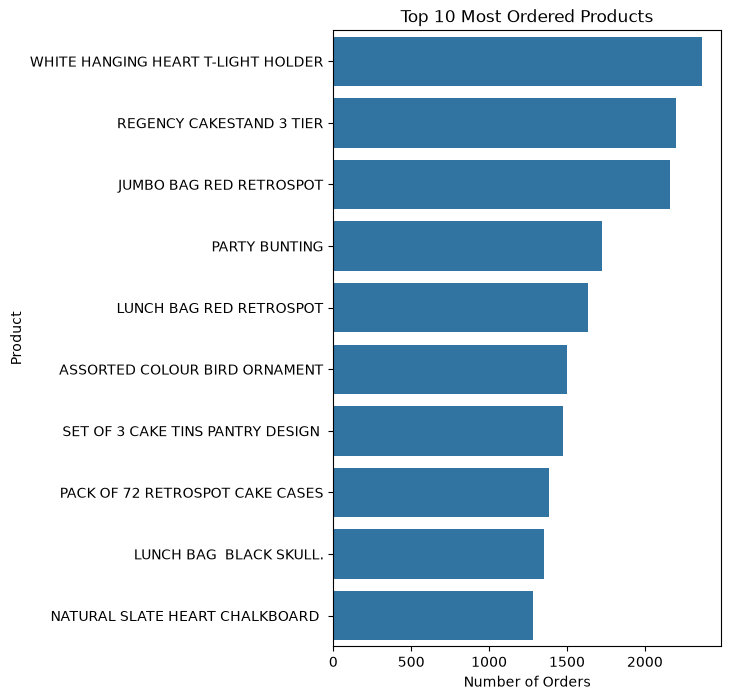

In [35]:
Top_Products=df['Description'].value_counts().head(10)
plt.figure(figsize=(5,8))
sns.barplot(x=Top_Products.values, y=Top_Products.index)

plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.title("Top 10 Most Ordered Products")
plt.show()

Top Products by Price

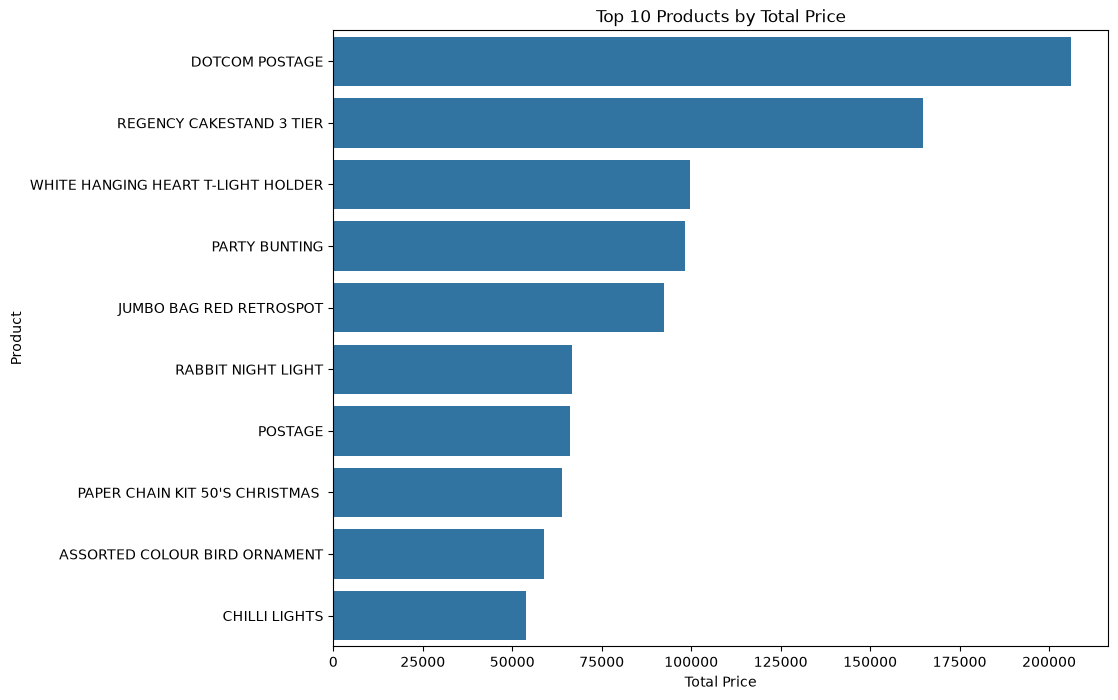

In [36]:
Top_Products_Price=df.groupby('Description')['Total Price'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,8))   
sns.barplot(x=Top_Products_Price.values, y=Top_Products_Price.index)
plt.xlabel("Total Price")
plt.ylabel("Product")
plt.title("Top 10 Products by Total Price")
plt.show()

Unit Price Quantity Scatter Plot

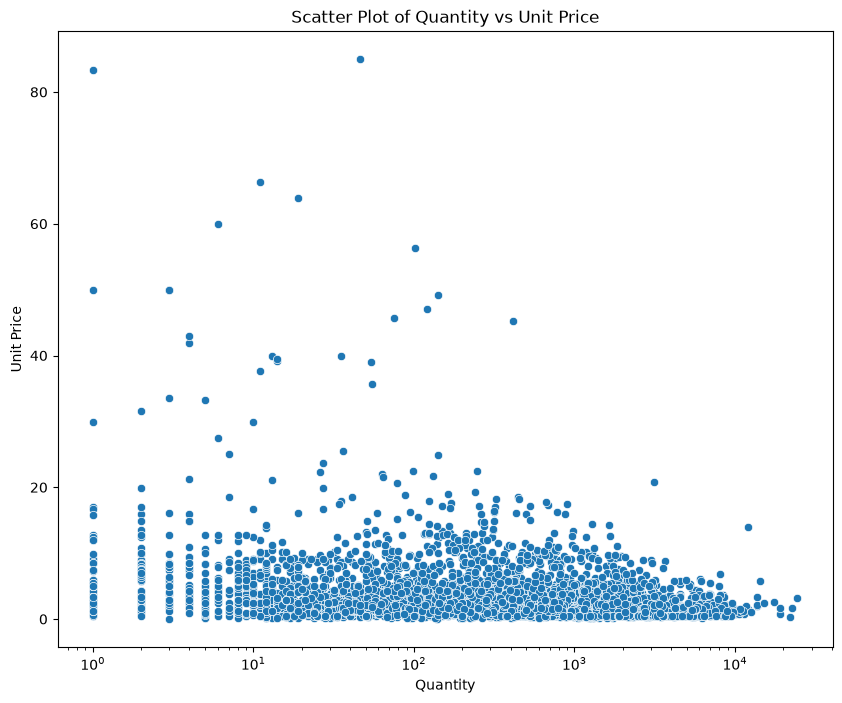

In [7]:
filtered = df[
    (df['Quantity'] > 0) &
    (df['Quantity'] < 100) &
    (df['UnitPrice'] > 0) &
    (df['UnitPrice'] < 100)
]
product_df = filtered.groupby('Description').agg({'Quantity':'sum', 'UnitPrice':'mean'}).reset_index()
plt.figure(figsize=(10,8))
sns.scatterplot(data=product_df, x='Quantity', y='UnitPrice')
plt.xscale("log")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Scatter Plot of Quantity vs Unit Price")
plt.show()

Product Revenue Analysis

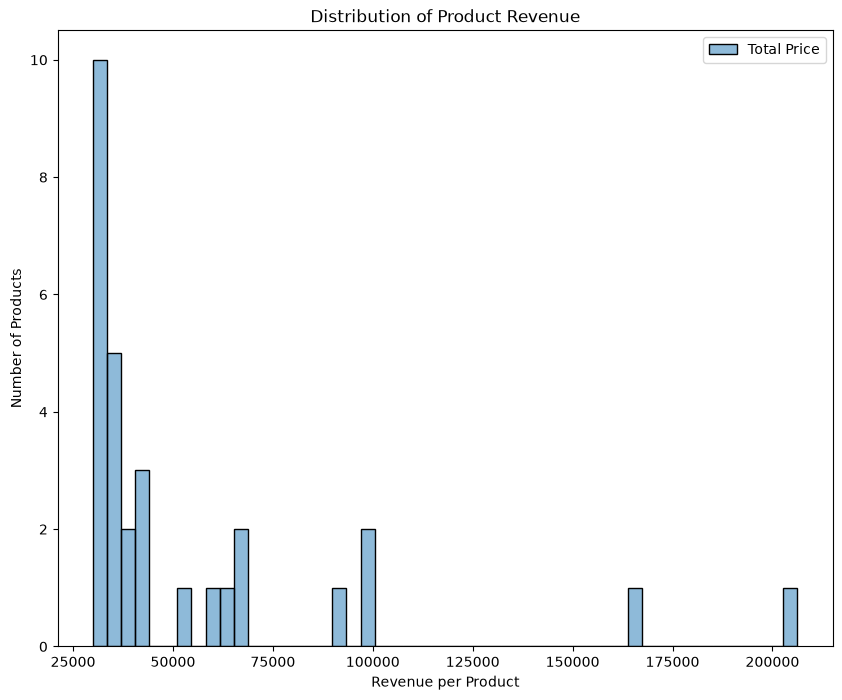

In [38]:
revenue_df = df.groupby('Description')['Total Price'].sum().reset_index().sort_values(by='Total Price', ascending=False).head(30)
plt.figure(figsize=(10,8))
sns.histplot(data=revenue_df, bins=50)
plt.xlabel("Revenue per Product")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Revenue")

plt.show()

Monthly Sales

In [39]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].dtype

dtype('<M8[us]')

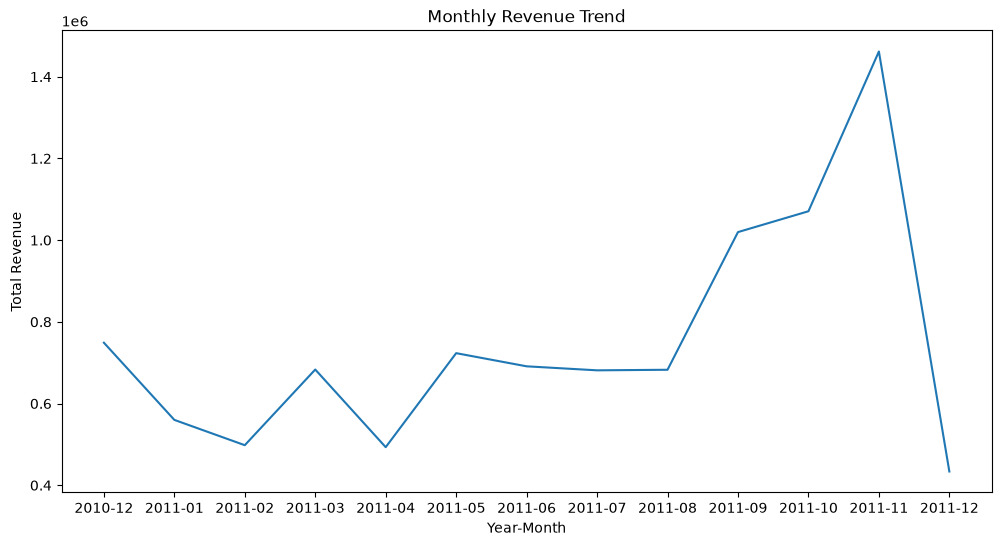

In [40]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales=df.groupby('YearMonth')['Total Price'].sum().reset_index()

monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Total Price')
plt.xlabel("Year-Month")    
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.show()

WeekDay Sales

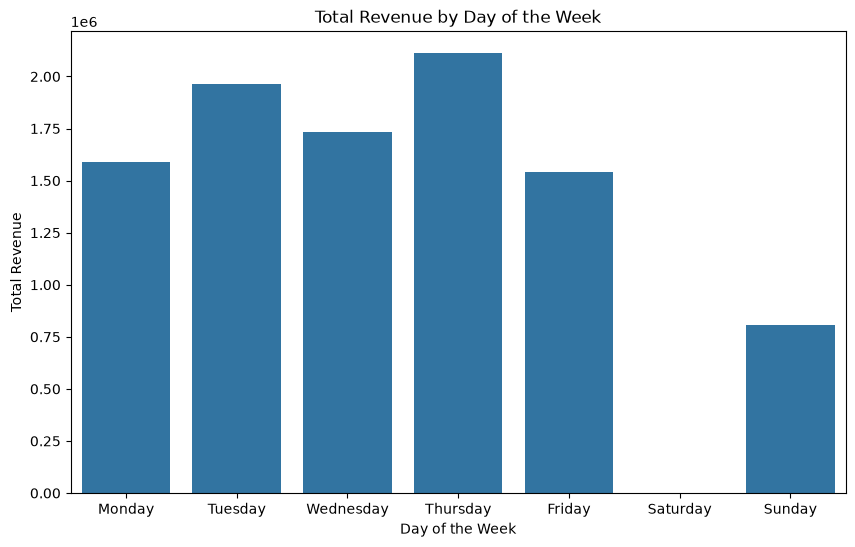

In [41]:
daily_sales = df.groupby('Day')['Total Price'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=daily_sales, x='Day', y='Total Price', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xlabel("Day of the Week")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Day of the Week")
plt.show()

Hourly Sales Analysis

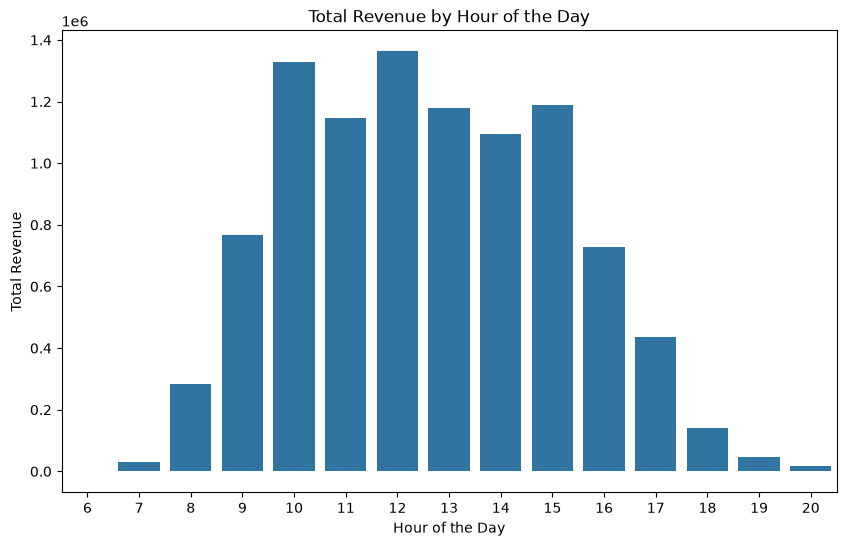

In [42]:
hourly_sales = df.groupby('Hour')['Total Price'].sum().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=hourly_sales, x='Hour', y='Total Price')
plt.xlabel("Hour of the Day")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Hour of the Day")
plt.show()


Monthly_Orders

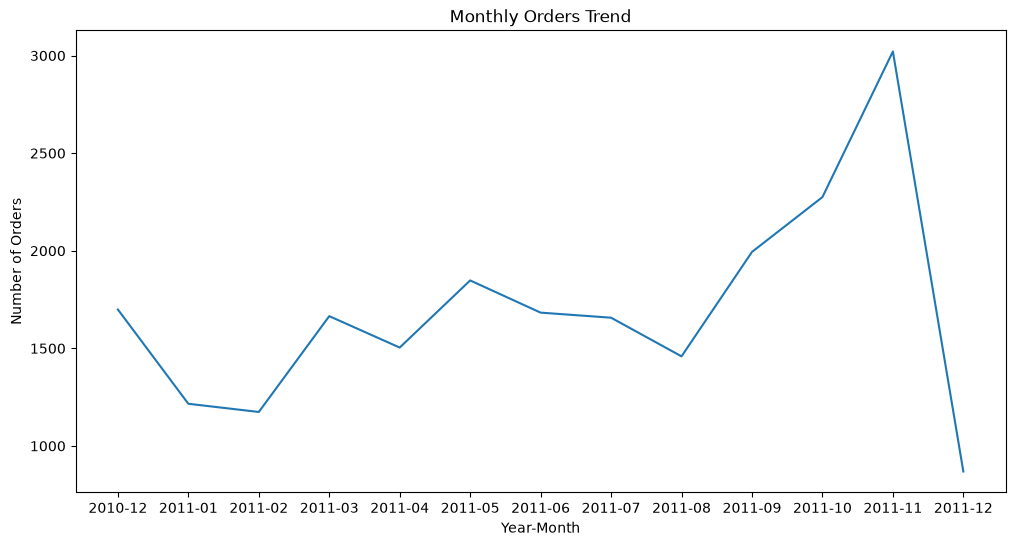

In [43]:
sales_df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

monthly_orders = (
    sales_df.groupby('YearMonth')['InvoiceNo']
            .nunique()
            .reset_index()
)
monthly_orders['YearMonth'] = monthly_orders['YearMonth'].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_orders, x='YearMonth', y='InvoiceNo' )
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Orders Trend")
plt.show()

Geographical Analysis

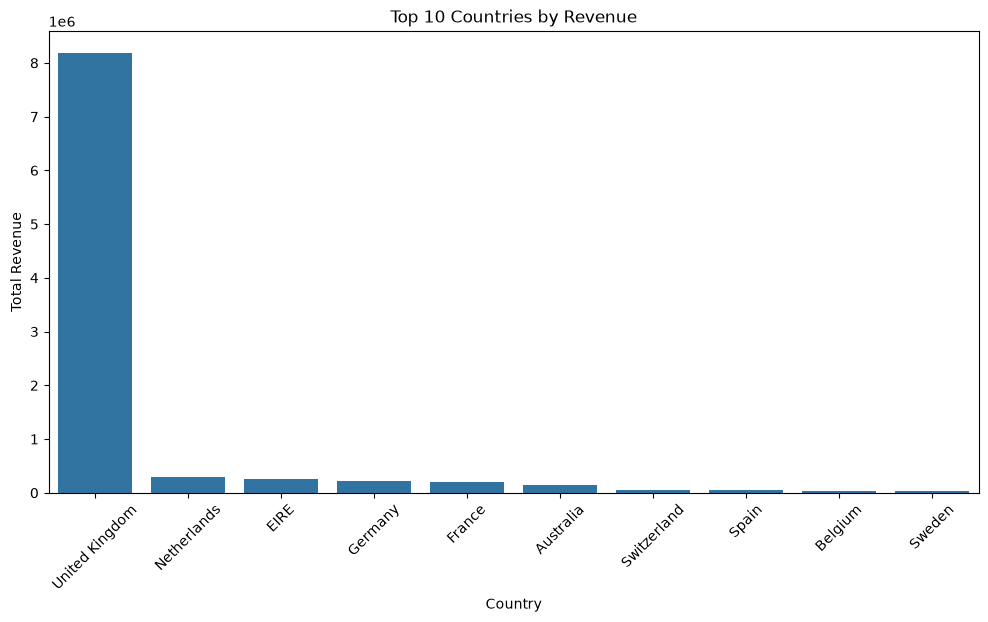

In [44]:
revenue_by_country = df.groupby('Country')['Total Price'].sum().reset_index().sort_values(by='Total Price', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=revenue_by_country, x='Country', y='Total Price')
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Top 10 Countries by Revenue")
plt.xticks(rotation=45)
plt.show()

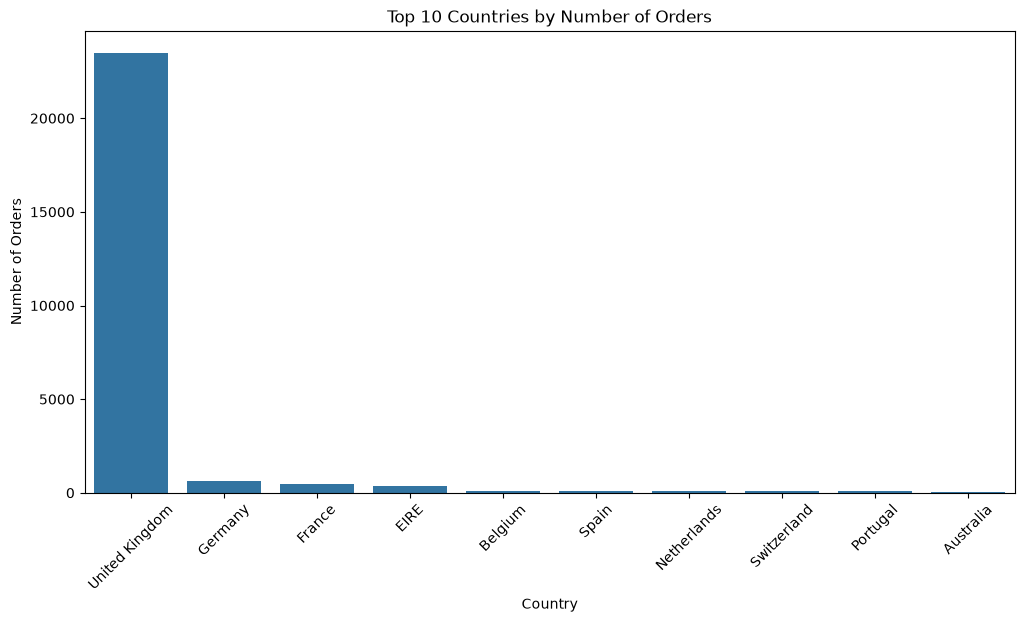

In [45]:
order_by_country = df.groupby('Country')['InvoiceNo'].nunique().reset_index().sort_values(by='InvoiceNo', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=order_by_country, x='Country', y='InvoiceNo')
plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.title("Top 10 Countries by Number of Orders")
plt.xticks(rotation=45)
plt.show()


Registered vs Anonymous

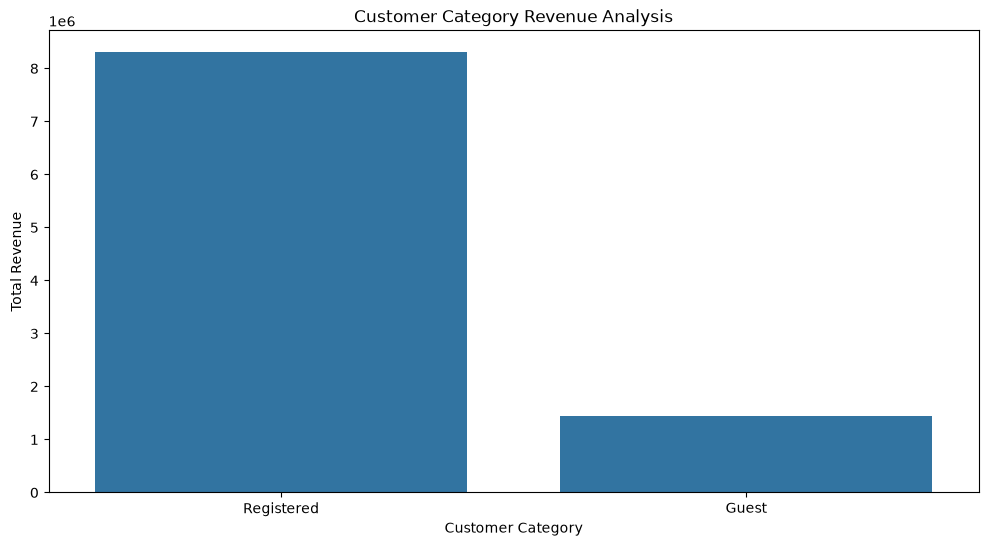

In [46]:
customer_revenue = (
    df.groupby('Customer_category')['Total Price']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
plt.figure(figsize=(12,6))
sns.barplot(data=customer_revenue,x='Customer_category',y='Total Price')
plt.xlabel("Customer Category")
plt.ylabel("Total Revenue")
plt.title("Customer Category Revenue Analysis")
plt.show()


# ❌ Cancellation Analysis

## Business Question

Which products experience the highest number of cancellations?

Understanding cancellation patterns helps identify potential issues related to product quality, customer satisfaction, or operational processes.

In [47]:
cancelation_count = df[df['Cancelled']=='Yes'].count()
cancelation_percentage=cancelation_count/len(df)

Text(0.5, 1.0, 'Most Cancelled Products')

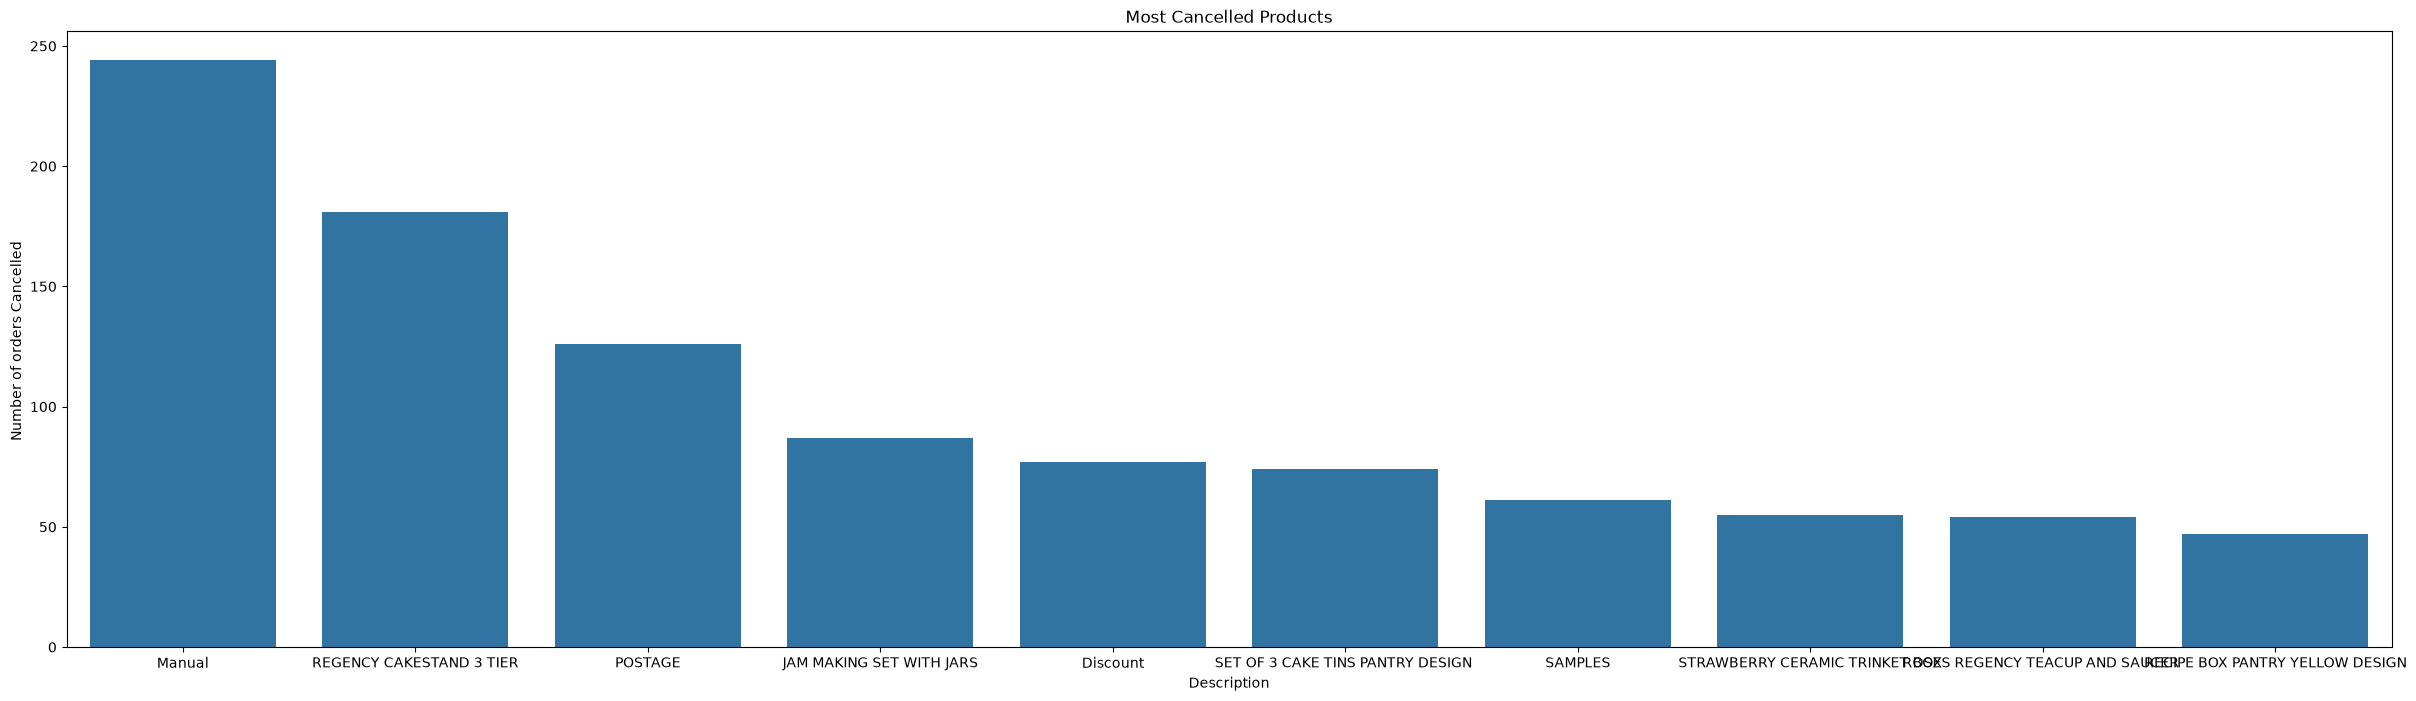

In [48]:
cancelled_df = df[df['Cancelled']=='Yes']
cancelled_rows = (
    cancelled_df.groupby('Description')['InvoiceNo']
                .count()
                .reset_index(name='CancelledOrders')
                .sort_values(by='CancelledOrders', ascending=False).head(10)
)



plt.figure(figsize=(30,8))
sns.barplot(data=cancelled_rows,x='Description',y='CancelledOrders')
plt.xlabel('Description')
plt.ylabel('Number of orders Cancelled ')
plt.title('Most Cancelled Products')

Text(0.5, 1.0, 'Cancelled Orders  by Month')

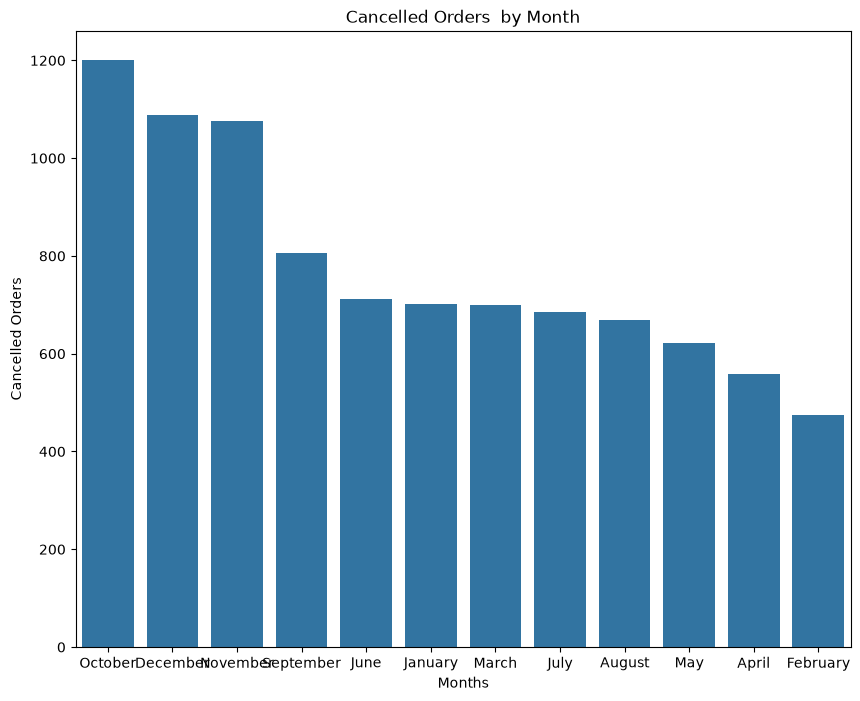

In [49]:
cancelled_df=df[df['Cancelled']=='Yes']
cancelled_by_month=(
    cancelled_df.groupby('Month')['InvoiceNo'].count().reset_index(name="OrderCancelled").sort_values(by='OrderCancelled' ,ascending=False)
)
cancelled_by_month.head()

plt.figure(figsize=(10,8))
sns.barplot(data=cancelled_by_month,x='Month',y='OrderCancelled')
plt.xlabel('Months')
plt.ylabel('Cancelled Orders')
plt.title('Cancelled Orders  by Month')

Text(0.5, 1.0, 'Cancellation by Country')

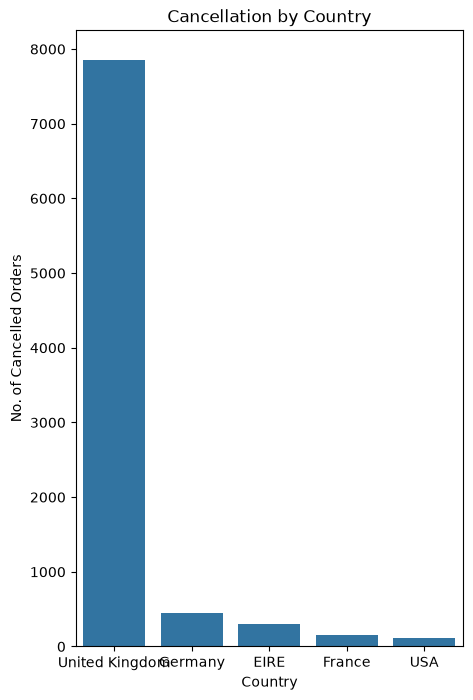

In [50]:
cancelled_by_country=(
    cancelled_df.groupby('Country')['InvoiceNo'].count().reset_index(name='CancelledOrders').sort_values(by='CancelledOrders',ascending=False).head(5)
)

plt.figure(figsize=(5,8))
sns.barplot(data=cancelled_by_country,x='Country',y='CancelledOrders')
plt.xlabel('Country')
plt.ylabel("No. of Cancelled Orders")
plt.title("Cancellation by Country")

# 📈 Pareto Analysis (80/20 Rule)

## Business Question

Which products generate the majority of the company's revenue?

The Pareto Principle states that a small percentage of products often contribute to a large percentage of total revenue.

This analysis identifies those high-impact products.

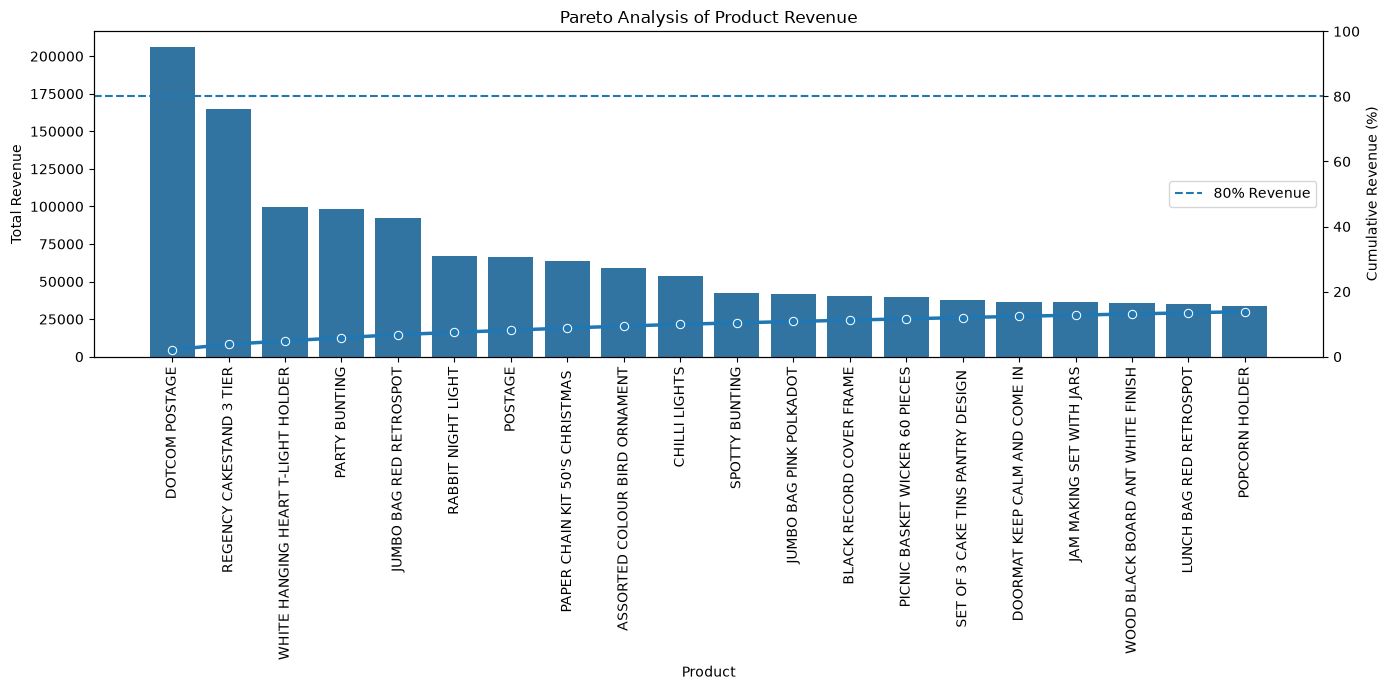

Products contributing approximately 80% of revenue: 761
Total unique products: 4224
Percentage of products contributing 80% revenue: 18.02%


In [51]:
revenue_by_product = (
    df.groupby('Description')['Total Price']
      .sum()
      .reset_index(name='TotalRevenue')
      .sort_values(by='TotalRevenue', ascending=False)
      .reset_index(drop=True)
)


total_revenue = revenue_by_product['TotalRevenue'].sum()

revenue_by_product['RevenuePercent'] = (
    revenue_by_product['TotalRevenue'] / total_revenue
) * 100


revenue_by_product['CumulativePercentage'] = (
    revenue_by_product['RevenuePercent'].cumsum()
)


pareto_plot = revenue_by_product.head(20).copy()


fig, ax1 = plt.subplots(figsize=(14, 7))


sns.barplot(
    data=pareto_plot,
    x='Description',
    y='TotalRevenue',
    ax=ax1
)

ax1.set_xlabel('Product')
ax1.set_ylabel('Total Revenue')
ax1.tick_params(axis='x', rotation=90)


ax2 = ax1.twinx()

sns.lineplot(
    data=pareto_plot,
    x='Description',
    y='CumulativePercentage',
    marker='o',
    linewidth=2.5,
    ax=ax2
)

ax2.set_ylabel('Cumulative Revenue (%)')
ax2.set_ylim(0, 100)


ax2.axhline(
    y=80,
    linestyle='--',
    label='80% Revenue'
)

ax2.legend(loc='center right')

plt.title('Pareto Analysis of Product Revenue')
plt.tight_layout()
plt.show()


products_to_80 = (
    revenue_by_product['CumulativePercentage']
    .searchsorted(80) + 1
)

total_products = len(revenue_by_product)

product_percentage = (
    products_to_80 / total_products
) * 100

print(f"Products contributing approximately 80% of revenue: {products_to_80}")
print(f"Total unique products: {total_products}")
print(f"Percentage of products contributing 80% revenue: {product_percentage:.2f}%")

# 🏷️ ABC Inventory Analysis

## Business Question

Which products should receive the highest inventory priority?

Products are classified based on cumulative revenue contribution.

### Category A

Top 80% of cumulative revenue.

### Category B

Next 15% of cumulative revenue.

### Category C

Remaining 5% of cumulative revenue.

ABC Analysis helps businesses optimize inventory management and focus resources on the most valuable products.

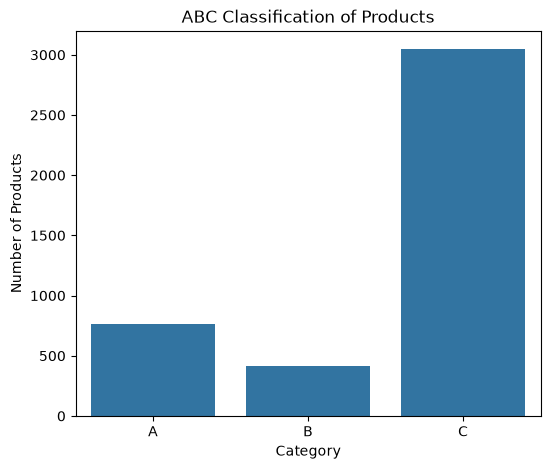

In [52]:
def abc_category(cum_percentage):
    if cum_percentage<=80:
        return 'A'
    elif cum_percentage<=90:
        return 'B'
    else:
        return 'C'
    
revenue_by_product['Category']=revenue_by_product['CumulativePercentage'].apply(abc_category)

abc_summary=(
    revenue_by_product.groupby('Category').size().reset_index(name='NumberOfProducts')
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=abc_summary,
    x='Category',
    y='NumberOfProducts'
)

plt.title("ABC Classification of Products")
plt.xlabel("Category")
plt.ylabel("Number of Products")

plt.show()

In [53]:
abc_stats = (
    revenue_by_product.groupby('Category')
    .agg(
        Products=('Description', 'count'),
        TotalRevenue=('TotalRevenue', 'sum'),
        AvgRevenue=('TotalRevenue', 'mean')
    )
    .reset_index()
)
abc_stats.head()

,Category,Products,TotalRevenue,AvgRevenue
0,A,760,7797628.880,10260.038000
1,B,418,973919.290,2329.950455
2,C,3046,976199.764,320.485806


# 💡 Key Business Recommendations

Based on the analysis, the following recommendations are proposed:

### 📦 Inventory Management

- Prioritize Category A products.
- Maintain sufficient inventory for high-revenue products.

### 📈 Sales Strategy

- Increase promotional efforts for medium-performing products.
- Monitor slow-moving products for potential discontinuation.

### ❌ Operational Improvements

- Investigate products with high cancellation rates.
- Improve quality control and shipping processes.

### 🌍 Market Expansion

- Continue strengthening presence in top-performing countries.
- Explore growth opportunities in emerging markets.